In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.70G/2.70G [02:05<00:00, 23.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import glob as gb
import cv2

In [5]:
train='/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'

In [24]:
len(train)

161

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

size = 224  # Keep original size

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train,
    target_size=(size, size),
    batch_size=64,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train,
    target_size=(size, size),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, save_weights_only=False)
]


Found 56251 images belonging to 38 classes.
Found 14044 images belonging to 38 classes.


In [ ]:
train_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

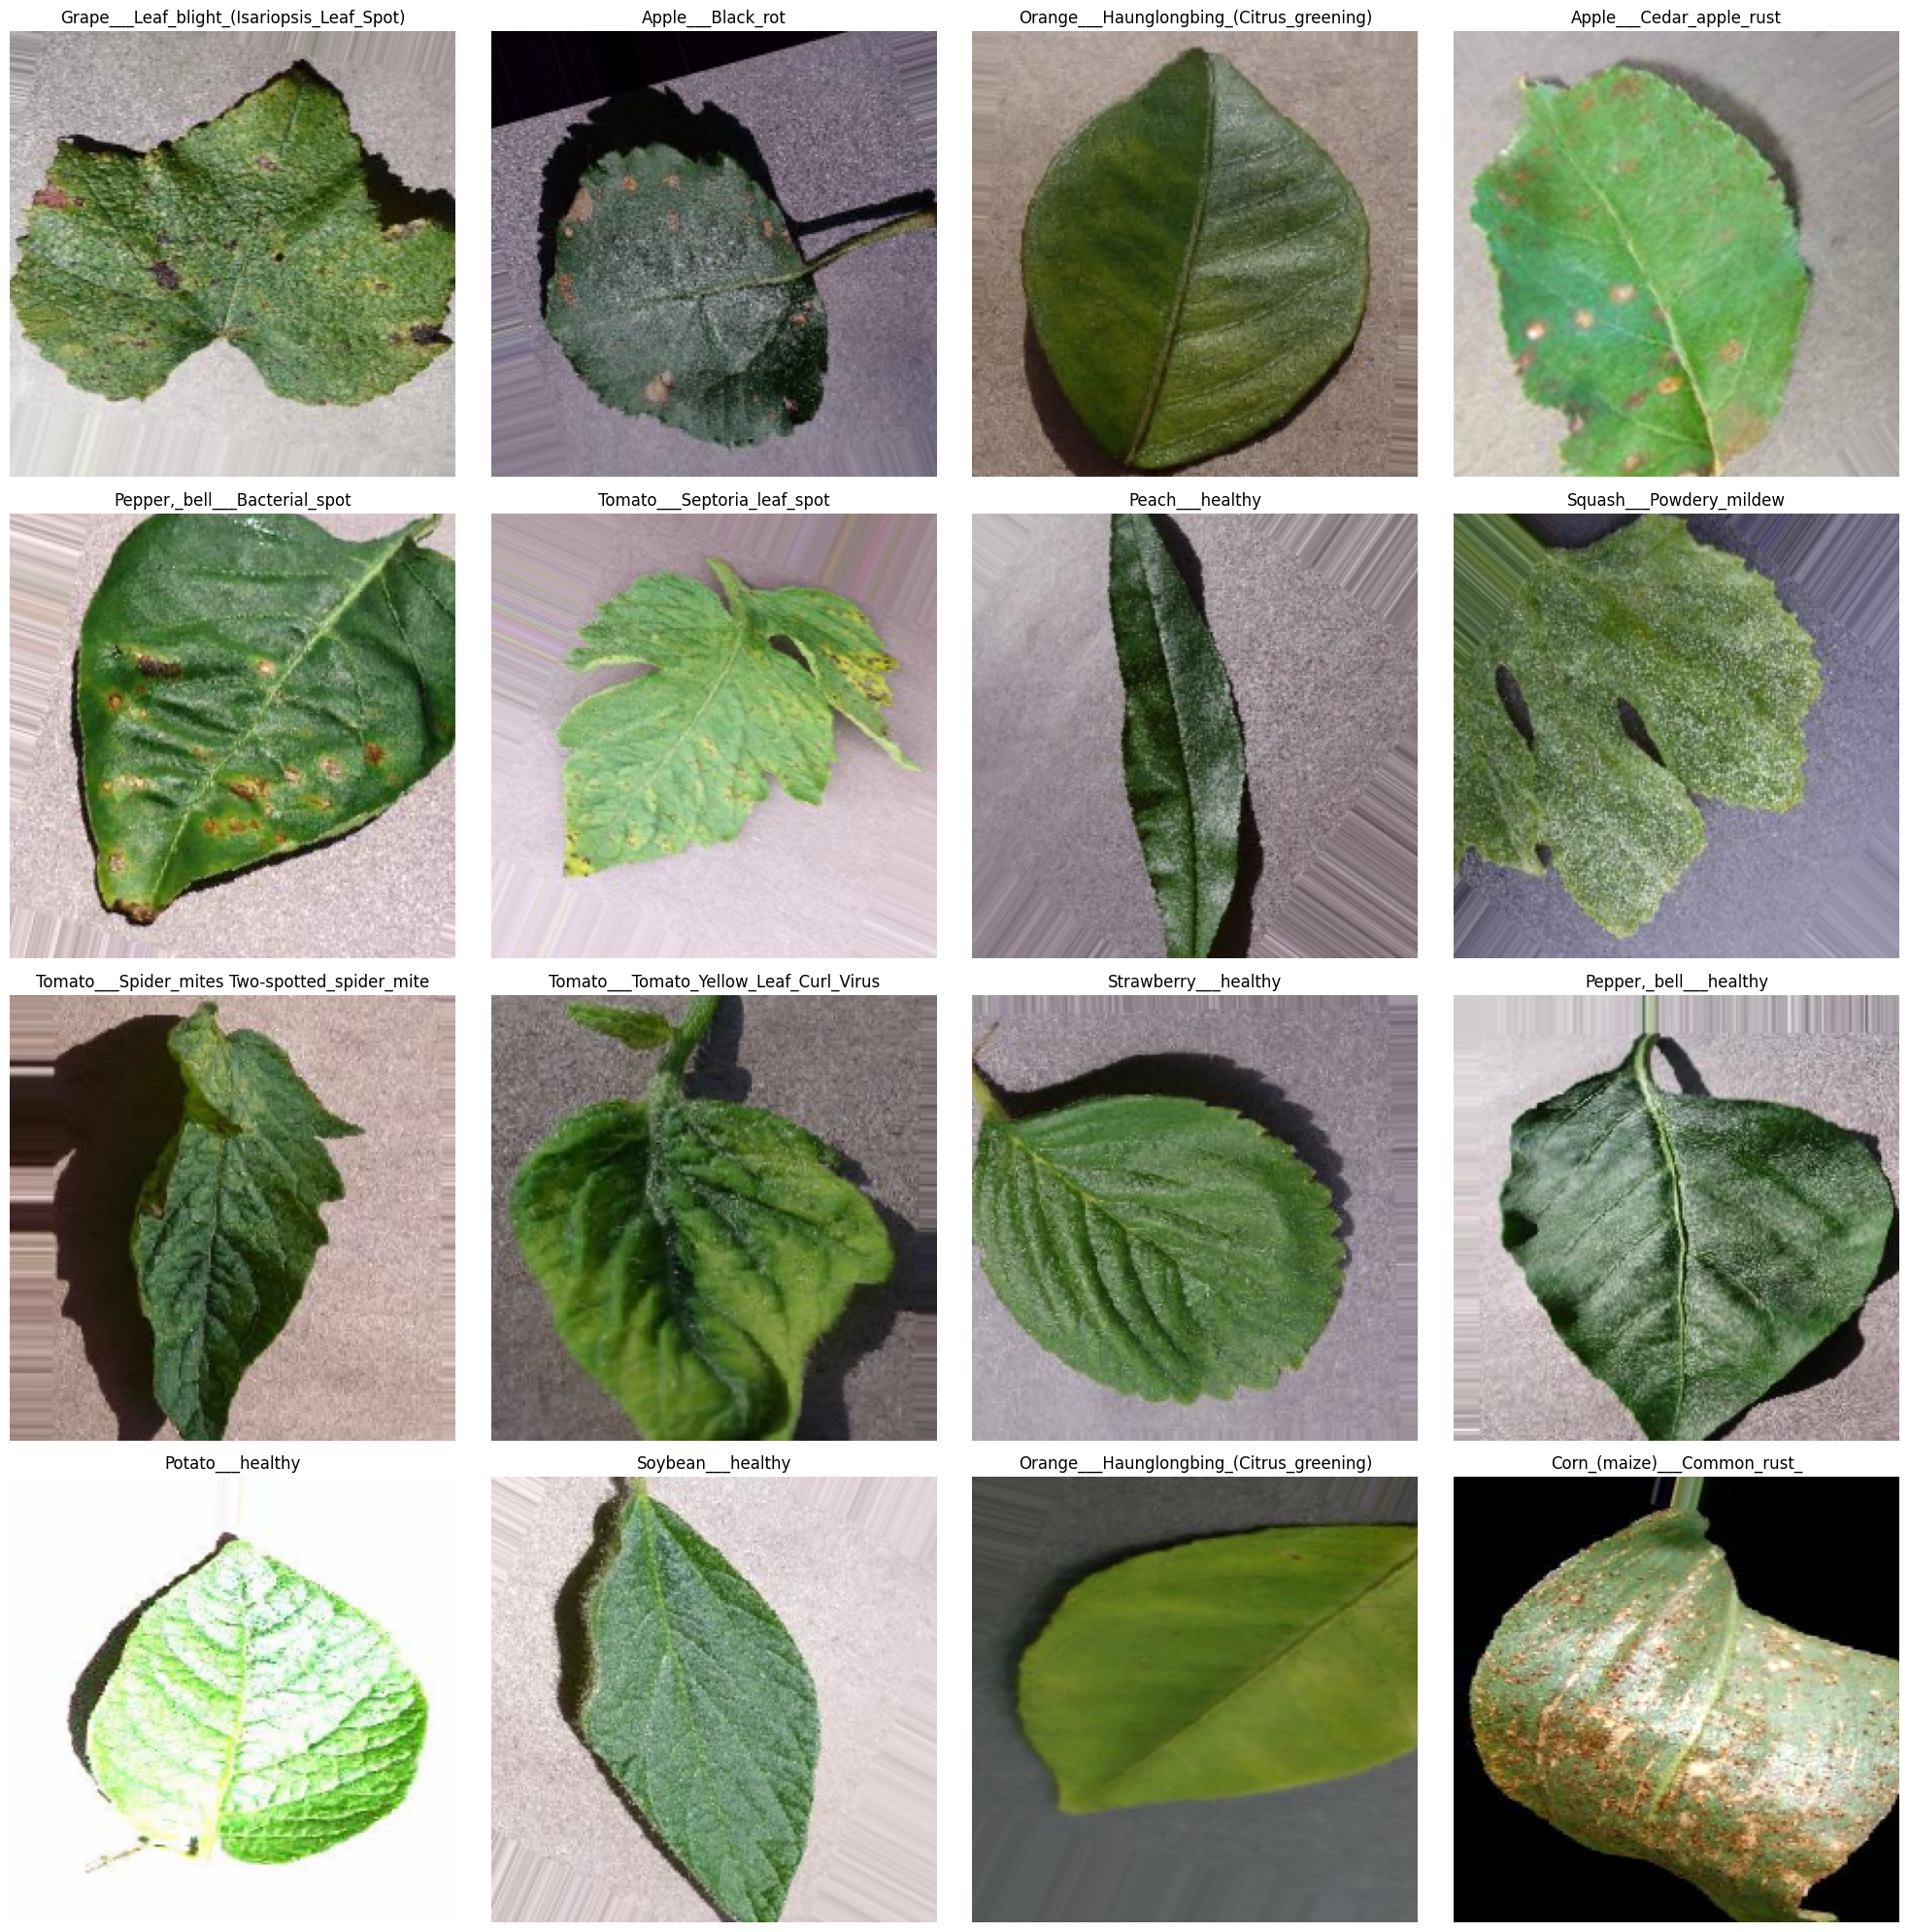

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

classes = list(train_generator.class_indices.keys())  # Get class labels

plt.figure(figsize=(20, 20))  # Set figure size

for X_batch, y_batch in train_generator:
    for i in range(16):  # Display 16 images
        plt.subplot(4, 4, i + 1)  # Create 4x4 grid
        plt.imshow(X_batch[i])  # Display image
        plt.title(classes[np.argmax(y_batch[i])])  # Corrected class label extraction
        plt.axis('off')
    plt.tight_layout()
    plt.show()  # Show all images in a single figure
    break  # Break after first batch


In [29]:
valid='/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [30]:
valid_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
    validation_split=0.1,
).flow_from_directory(
    valid,
    target_size=(size,size),
    batch_size=164,
    class_mode='categorical',
    color_mode='rgb',
    subset='validation',
    shuffle=False
)


Found 1742 images belonging to 38 classes.


In [31]:
test='/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
test_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
).flow_from_directory(test,
                      target_size=(224,224),
                      batch_size=164,
                      class_mode='categorical',
                      color_mode='rgb',
                      shuffle=False
)

Found 17572 images belonging to 38 classes.


In [ ]:
test_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, BatchNormalization, Dropout,
    GlobalAveragePooling2D, LeakyReLU, Dense
)

# Enable mixed precision training for faster computation
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def create_model():
    model = keras.models.Sequential()

    model.add(Conv2D(filters=32, kernel_size=3, strides=1, padding='same',
                     name="Conv1", input_shape=(128, 128, 3)))  # Reduced image size
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization(name="BatchNorm1"))
    model.add(MaxPool2D(pool_size=2, name="Pool1"))

    model.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', name='Conv2'))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization(name="BatchNorm2"))
    model.add(MaxPool2D(pool_size=2, name="Pool2"))

    model.add(Conv2D(filters=128, kernel_size=3, strides=1, padding='same', name='Conv3'))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization(name="BatchNorm3"))
    model.add(MaxPool2D(pool_size=2, name="Pool3"))

    model.add(Conv2D(filters=256, kernel_size=3, strides=1, padding='same', name='Conv4'))  # Reduced filters
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization(name="BatchNorm4"))
    model.add(MaxPool2D(pool_size=2, name="Pool4"))

    # Global Average Pooling instead of Flatten
    model.add(GlobalAveragePooling2D(name='GAP'))

    # Dense Layers
    model.add(Dense(128, name='Dense1', dtype='float32'))  # Ensure float32 for dense layers
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.3, name="Dropout1"))  # Reduced dropout

    model.add(Dense(64, name='Dense2', dtype='float32'))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.3, name="Dropout2"))

    # Output Layer
    model.add(Dense(38, activation=keras.activations.softmax, name='Output', dtype='float32'))

    return model

In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True, verbose=1)

model_checkpoint = ModelCheckpoint('best_model.weights.h5', monitor='val_loss', save_best_only=True,
                                   save_weights_only=True, mode='min', verbose=1)


model_ReduceLRonPlateau = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=7,
                                            min_lr=1e-6, mode='min', verbose=1)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

]



In [21]:
from tensorflow.keras.metrics import Precision, Recall

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])


In [1]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')



In [11]:
model.save('my_model.keras')  # Saves in the new .keras format



In [9]:
from tensorflow.keras.models import load_model

model = load_model('my_model.keras')  # Loads the saved model


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 32 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 28 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [23]:
from tensorflow.keras.optimizers import AdamW
optimizer = AdamW(learning_rate=0.001)
from tensorflow.keras.metrics import Precision, Recall

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])



In [11]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [12]:
tf.config.optimizer.set_jit(True)  # Enable XLA


In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 180s 192ms/step - accuracy: 0.9368 - loss: 0.2173 - precision: 0.9500 - recall: 0.9228 - val_accuracy: 0.8003 - val_loss: 0.7783 - val_precision: 0.8263 - val_recall: 0.7857 - learning_rate: 0.0010
Epoch 2/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 162s 184ms/step - accuracy: 0.9461 - loss: 0.1858 - precision: 0.9580 - recall: 0.9343 - val_accuracy: 0.9259 - val_loss: 0.2452 - val_precision: 0.9321 - val_recall: 0.9203 - learning_rate: 0.0010
Epoch 3/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 159s 181ms/step - accuracy: 0.9515 - loss: 0.1623 - precision: 0.9629 - recall: 0.9414 - val_accuracy: 0.8300 - val_loss: 0.7758 - val_precision: 0.8452 - val_recall: 0.8218 - learning_rate: 0.0010
Epoch 4/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 158s 179ms/step - accuracy: 0.9515 - loss: 0.1651 - precision: 0.9616 - recall: 0.9430 - val_accuracy: 0.9502 - val_loss: 0.1621 - val_precision: 0.9540 - val_recall: 0.9465 - learning_rate: 0.0010
Epoch 5/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 158s 179

879/879 ━━━━━━━━━━━━━━━━━━━━ 162s 184ms/step - accuracy: 0.9630 - loss: 0.1270 - precision: 0.9697 - recall: 0.9565 - val_accuracy: 0.9630 - val_loss: 0.1362 - val_precision: 0.9659 - val_recall: 0.9608 - learning_rate: 0.0010
Epoch 7/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9605 - loss: 0.1349 - precision: 0.9678 - recall: 0.9534

879/879 ━━━━━━━━━━━━━━━━━━━━ 167s 190ms/step - accuracy: 0.9605 - loss: 0.1349 - precision: 0.9678 - recall: 0.9534 - val_accuracy: 0.9682 - val_loss: 0.1100 - val_precision: 0.9718 - val_recall: 0.9654 - learning_rate: 0.0010
Epoch 8/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9640 - loss: 0.1207 - precision: 0.9703 - recall: 0.9585

879/879 ━━━━━━━━━━━━━━━━━━━━ 162s 184ms/step - accuracy: 0.9640 - loss: 0.1207 - precision: 0.9703 - recall: 0.9585 - val_accuracy: 0.9755 - val_loss: 0.0775 - val_precision: 0.9778 - val_recall: 0.9734 - learning_rate: 0.0010
Epoch 9/10
879/879 ━━━━━━━━━━━━━━━━━━━━ 159s 180ms/step - accuracy: 0.9675 - loss: 0.1085 - precision: 0.9733 - recall: 0.9633 - val_accuracy: 0.9156 - val_loss: 0.3874 - val_precision: 0.9236 - val_recall: 0.9119 - learning_rate: 0.0010
Epoch 10/10
529/879 ━━━━━━━━━━━━━━━━━━━━ 54s 157ms/step - accuracy: 0.9678 - loss: 0.1121 - precision: 0.9730 - recall: 0.9618

In [26]:
import seaborn as sns

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

precision = history.history['precision']
val_precision = history.history['val_precision']

recall = history.history['recall']
val_recall = history.history['val_recall']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

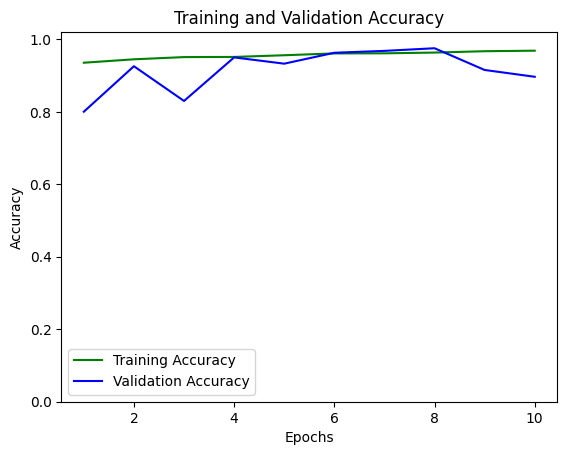

In [29]:

plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1.02)
plt.show()

In [32]:

model_evaluate = model.evaluate(test_generator)
print("loss:", model_evaluate[0])
print("accuracy:", model_evaluate[1])
print("precision:", model_evaluate[2])
print("recall:", model_evaluate[3])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


108/108 ━━━━━━━━━━━━━━━━━━━━ 47s 365ms/step - accuracy: 0.9831 - loss: 0.0527 - precision: 0.9859 - recall: 0.9817
loss: 0.06836821138858795
accuracy: 0.9791144728660583
precision: 0.9818223118782043
recall: 0.9774641394615173


In [33]:
model.save('my_model.keras')